In [16]:
from __future__ import annotations

import os
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


# --- CẤU HÌNH HỆ THỐNG ---
# Gom tất cả vào một Class duy nhất để quản lý đường dẫn tập trung
class HMConfig:
    # 1. Kết nối Drive (Chỉ cần chạy 1 lần)
    DRIVE_PATH = Path("")

    # 2. Định nghĩa các đường dẫn file gốc
    TRANSACTIONS_CSV = DRIVE_PATH / "transactions_train.csv"
    CUSTOMERS_CSV    = DRIVE_PATH / "customers.csv"
    ARTICLES_CSV     = DRIVE_PATH / "articles.csv"

    # 3. Định nghĩa thư mục đầu ra
    OUTPUT_DIR = Path("./outputs")

    # Tạo thư mục nếu chưa có
    @classmethod
    def setup(cls):
        if not cls.DRIVE_PATH.exists():
             print(f"Cảnh báo: Không tìm thấy thư mục {cls.DRIVE_PATH}. Hãy kiểm tra lại kết nối Drive!")
        cls.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- THIẾT LẬP MÔI TRƯỜNG ---

HMConfig.setup()

# Thiết lập giao diện biểu đồ
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid") # Giúp biểu đồ Seaborn mặc định đẹp hơn


In [17]:


# =========================
# 1) BIG DATA INGESTION
# =========================
def scan_transactions_lazy(csv_path: Path) -> pl.LazyFrame:
    """
    Đọc transactions theo lazy mode, tối ưu schema và bộ nhớ.
    """
    return (
        pl.scan_csv(
            csv_path,
            # 1. Ép kiểu ngay từ khi quét file để tiết kiệm tài nguyên
            schema_overrides={
                "article_id": pl.Int32,
                "price": pl.Float32,
                "sales_channel_id": pl.Int8,
            },
            # 2. Để Polars tự nhận diện t_dat là Date ngay từ đầu (nếu format chuẩn ISO)
            try_parse_dates=True,
            infer_schema_length=10000, # Tăng độ dài nhận diện để tránh sai kiểu dữ liệu
            ignore_errors=True,
            low_memory=True, # Kích hoạt chế độ tiết kiệm RAM của Polars
        )
        .with_columns([
            # 3. Nếu t_dat vẫn là chuỗi, xử lý triệt để
            pl.col("t_dat").cast(pl.Date, strict=False),

            # 4. Hash customer_id thành số nguyên (Int64) để join/filter nhanh hơn 10 lần
            pl.col("customer_id").hash(seed=42).alias("customer_key"),

            # 5. Ép kiểu customer_id về Categorical để tiết kiệm RAM nếu cần giữ lại chuỗi gốc
            # pl.col("customer_id").cast(pl.Categorical),
        ])
    )

def build_transaction_light_parquet(csv_path: Path, out_path: Path) -> None:
    """
    Ghi dữ liệu ra Parquet trực tiếp từ ổ đĩa (Streaming).
    """
    print(f"--- Đang chuyển đổi {csv_path.name} sang Parquet (Streaming)... ---")
    lf = scan_transactions_lazy(csv_path)

    # Sử dụng sink_parquet là lựa chọn tối ưu nhất cho Big Data
    lf.sink_parquet(out_path, compression="zstd", row_group_size=100_000)
    print(f"Đã lưu file Parquet tại: {out_path}")



In [18]:

# =========================
# 2) TIME FEATURES + TEST SET
# =========================
def add_time_features(lf: pl.LazyFrame) -> pl.LazyFrame:
    """
    Trích xuất các đặc trưng thời gian từ cột t_dat.
    Sử dụng ISO week để đảm bảo tính chính xác toàn cầu.
    """
    return lf.with_columns(
        [
            pl.col("t_dat").dt.year().cast(pl.Int16).alias("year"),
            pl.col("t_dat").dt.month().cast(pl.Int8).alias("month"),
            pl.col("t_dat").dt.week().cast(pl.Int8).alias("week"), # Sửa từ .week() sang .iso_week()
            pl.col("t_dat").dt.weekday().cast(pl.Int8).alias("day_of_week"),
        ]
    )


def save_recent_months_subset(
    lf: pl.LazyFrame,
    months_back: int = 6,
    out_path: Optional[Path] = None
) -> pl.DataFrame:
    """
    Lọc và lưu tập dữ liệu giao dịch trong n tháng gần nhất.
    Sử dụng sink_parquet để ghi dữ liệu lớn mà không tốn RAM.
    """
    if out_path is None:
        out_path = HMConfig.OUTPUT_DIR / f"transactions_last_{months_back}_months.parquet"

    # 1. Tìm ngày gần nhất trong dữ liệu
    max_date = lf.select(pl.col("t_dat").max()).collect().item()

    # 2. Tính điểm cắt (Cutoff) lùi lại n tháng
    # Chuyển max_date sang định dạng date của Polars để filter chính xác
    cutoff_date = max_date - pd.DateOffset(months=months_back)
    cutoff_val = cutoff_date.date()

    print(f"--- Đang lọc dữ liệu từ ngày {cutoff_val} đến {max_date} ---")

    # 3. Thực hiện lọc và thêm tính năng thời gian
    recent_lf = (
        lf.filter(pl.col("t_dat") >= cutoff_val)
        .pipe(add_time_features) # Dùng pipe để code trông gọn gàng hơn
    )

    # 4. Ghi trực tiếp ra file (Cực kỳ tối ưu RAM)
    recent_lf.sink_parquet(out_path, compression="zstd")

    # Chỉ collect về RAM sau khi đã ghi file nếu thực sự cần dùng tiếp
    return recent_lf.collect()

In [19]:

# =========================
# 3) PRODUCT EDA (OPTIMIZED)
# =========================

def top_100_products(lf_tx: pl.LazyFrame, lf_articles: pl.LazyFrame, metric: str = "revenue") -> pl.DataFrame:
    # 1. Xác định công thức tính toán
    if metric == "revenue":
        agg_expr = pl.col("price").sum().alias("value")
        title = "Top 100 sản phẩm doanh thu cao nhất"
        xlabel = "Tổng doanh thu"
    elif metric == "volume":
        agg_expr = pl.len().alias("value")
        title = "Top 100 sản phẩm bán chạy nhất"
        xlabel = "Số lượng bán ra"
    else:
        raise ValueError("metric phải là 'revenue' hoặc 'volume'")

    # 2. Xử lý dữ liệu (Sử dụng Inner Join để tránh ID rác)
    result_lf = (
        lf_tx.group_by("article_id")
        .agg(agg_expr)
        .join(
            lf_articles.select(["article_id", "prod_name", "product_group_name", "index_name"]),
            on="article_id",
            how="inner"  # Sửa từ left sang inner để đảm bảo data sạch
        )
        .sort("value", descending=True)
    )

    # Thu thập kết quả (Chỉ lấy 100 dòng về RAM)
    result = result_lf.limit(100).collect()

    # 3. Trực quan hóa (Dùng Seaborn cho đẹp)
    plot_df = result.head(20).to_pandas()

    plt.figure(figsize=(12, 8))
    sns.barplot(data=plot_df, x="value", y="prod_name", palette="viridis")
    plt.title(f"{title} (Top 20)")
    plt.xlabel(xlabel)
    plt.ylabel("Tên sản phẩm")
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return result


def plot_monthly_revenue(lf_tx: pl.LazyFrame) -> pl.DataFrame:
    # Tối ưu: Tính toán ngay trên LazyFrame
    monthly = (
        add_time_features(lf_tx)
        .group_by(["year", "month"])
        .agg([
            pl.col("price").sum().alias("monthly_revenue"),
            pl.len().alias("monthly_volume"),
        ])
        .sort(["year", "month"])
        .collect()
    )

    pdf = monthly.to_pandas()
    # Format lại trục X: Year-Month
    pdf["year_month"] = pdf["year"].astype(str) + "-" + pdf["month"].astype(str).str.zfill(2)

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=pdf, x="year_month", y="monthly_revenue", marker="o", color="royalblue", linewidth=2.5)
    plt.xticks(rotation=45)
    plt.title("Biến động doanh thu theo thời gian", fontsize=14)
    plt.xlabel("Giai đoạn (Tháng)")
    plt.ylabel("Doanh thu")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return monthly


def plot_index_group_revenue(lf_tx: pl.LazyFrame, articles_df: pl.DataFrame) -> pl.DataFrame:
    """
    Phân tích doanh thu theo nhóm danh mục sản phẩm (Deep EDA)
    """
    result = (
        lf_tx.group_by("article_id")
        .agg(pl.col("price").sum().alias("revenue"))
        .join(
            articles_df.lazy().select(["article_id", "index_group_name"]),
            on="article_id",
            how="inner"
        )
        .group_by("index_group_name")
        .agg(pl.col("revenue").sum().alias("total_revenue"))
        .sort("total_revenue", descending=True)
        .collect()
    )

    pdf = result.to_pandas()

    plt.figure(figsize=(12, 6))
    # Dùng barplot ngang với màu sắc phân biệt
    sns.barplot(data=pdf, x="total_revenue", y="index_group_name", hue="index_group_name", palette="magma", legend=False)
    plt.title("Tỷ trọng doanh thu theo nhóm ngành hàng", fontsize=14)
    plt.xlabel("Tổng doanh thu")
    plt.ylabel("Nhóm ngành")
    plt.tight_layout()
    plt.show()

    return result

In [20]:


# =========================
# 4) CUSTOMERS / ARTICLES CLEANING
# =========================

def clean_customers(csv_path: Path, out_path: Optional[Path] = None) -> pl.DataFrame:
    if out_path is None:
        out_path = HMConfig.OUTPUT_DIR / "customers_clean.parquet"

    # Sử dụng scan_csv để tận dụng LazyFrame
    lf = pl.scan_csv(csv_path, infer_schema_length=1000, low_memory=True)

    cleaned = (
        lf.with_columns([
            # 1. Tạo customer_key
            pl.col("customer_id").hash(seed=42).alias("customer_key"),

            # 2. Xử lý Age: Lọc tuổi bất thường (12-100) và cast về Float32
            pl.when(
                (pl.col("age").is_null()) |
                (pl.col("age") < 12) |
                (pl.col("age") > 100)
            )
            .then(None)
            .otherwise(pl.col("age"))
            .cast(pl.Float32)
            .alias("age"),

            # 3. Chuẩn hóa club_member_status
            pl.col("club_member_status")
            .cast(pl.Utf8)
            .str.strip_chars()
            .str.to_uppercase()
            .fill_null("UNKNOWN")
            .alias("club_member_status"),

            # 4. Chuẩn hóa fashion_news_frequency
            pl.col("fashion_news_frequency")
            .cast(pl.Utf8)
            .str.strip_chars()
            .str.to_uppercase()
            .fill_null("UNKNOWN")
            .alias("fashion_news_frequency"),
        ])
        # 5. Điền giá trị thiếu của age bằng Median (sau khi đã lọc outliers)
        .with_columns(
            pl.col("age").fill_null(pl.col("age").median())
        )
        .collect()
    )

    cleaned.write_parquet(out_path, compression="zstd")
    print(f"Đã làm sạch Customers và lưu tại: {out_path}")
    return cleaned


def clean_articles(csv_path: Path, out_path: Optional[Path] = None) -> pl.DataFrame:
    if out_path is None:
        out_path = HMConfig.OUTPUT_DIR / "articles_clean.parquet"

    lf = pl.scan_csv(
        csv_path,
        infer_schema_length=1000,
        low_memory=True,
        schema_overrides={"article_id": pl.Int32}, # Ép kiểu ID về Int32 cho nhẹ
    )

    text_cols = [
        "prod_name", "product_type_name", "product_group_name",
        "graphical_appearance_name", "colour_group_name",
        "perceived_colour_value_name", "perceived_colour_master_name",
        "department_name", "index_name", "index_group_name",
        "section_name", "garment_group_name", "detail_desc",
    ]

    # Sử dụng list comprehension để viết code gọn hơn
    exprs = [
        pl.col(c)
        .cast(pl.Utf8)
        .str.strip_chars()
        .str.replace_all(r"\s+", " ") # Xóa khoảng trắng thừa giữa các từ
        .str.to_lowercase()
        .fill_null("unknown")
        .alias(c)
        for c in text_cols
    ]

    cleaned = (
        lf.with_columns(exprs)
        .filter(pl.col("article_id").is_not_null())
        .unique(subset=["article_id"], keep="first")
        .collect()
    )

    cleaned.write_parquet(out_path, compression="zstd")
    print(f"Đã làm sạch Articles và lưu tại: {out_path}")
    return cleaned

In [21]:


# =========================
# 5) RFM (OPTIMIZED: CAPPING + LOG1P + INTEGRITY)
# =========================

def filter_recent_transactions(tx_lf: pl.LazyFrame, months_back: int = 8) -> pl.LazyFrame:
    """
    Chỉ lấy N tháng gần nhất để đảm bảo tính thời điểm của hành vi khách hàng.
    """
    # Tìm ngày cuối cùng trong data
    max_date = tx_lf.select(pl.col("t_dat").max()).collect().item()
    # Tính điểm cắt
    cutoff_date = pd.Timestamp(max_date) - pd.DateOffset(months=months_back)

    return tx_lf.filter(pl.col("t_dat") >= cutoff_date.date())


def cap_price_outliers(tx_lf: pl.LazyFrame) -> pl.LazyFrame:
    """
    SỬA: Thay vì Filter (xóa), ta dùng Capping (kẹp biên).
    Giữ lại khách hàng nhưng giới hạn giá trị giao dịch tại ngưỡng 99%.
    """
    # Tính ngưỡng Percentile 99
    q99 = tx_lf.select(pl.col("price").quantile(0.99)).collect().item()

    # Nếu giá > p99 thì gán bằng p99, ngược lại giữ nguyên
    return tx_lf.with_columns(
        pl.when(pl.col("price") > q99)
        .then(pl.lit(q99))
        .otherwise(pl.col("price"))
        .alias("price")
    )


def build_rfm(
    lf_tx: pl.LazyFrame,
    months_back: int = 8,
    out_path: Optional[Path] = None
) -> pl.DataFrame:
    """
    Xây dựng bảng RFM sạch, không Outliers, giới hạn thời gian.
    """
    if out_path is None:
        out_path = HMConfig.OUTPUT_DIR / "customer_rfm_clean.parquet"

    # 1. Lọc thời gian và kẹp biên giá
    tx_recent = filter_recent_transactions(lf_tx, months_back=months_back)
    tx_recent = cap_price_outliers(tx_recent)

    # 2. Lấy ngày snapshot (ngày cuối cùng trong data)
    snapshot_date = tx_recent.select(pl.col("t_dat").max()).collect().item()

    # 3. Aggregation RFM
    rfm = (
        tx_recent.group_by("customer_id") # Gom nhóm theo ID gốc thay vì Key
        .agg([
            pl.col("t_dat").max().alias("last_purchase_date"),
            pl.len().alias("frequency"),
            pl.col("price").sum().alias("monetary"),
        ])
        .with_columns(
            (pl.lit(snapshot_date).cast(pl.Date) - pl.col("last_purchase_date"))
            .dt.total_days()
            .alias("recency")
        )
        # SỬA DÒNG NÀY: Giữ lại customer_id
        .select(["customer_id", "recency", "frequency", "monetary"])
        .collect()
    )

    # 4. Data Integrity: Chỉ giữ lại khách hàng có ID trong bảng customers_clean (nếu cần)
    # rfm = rfm.join(customers_clean, on="customer_key", how="inner")

    rfm.write_parquet(out_path, compression="zstd")
    print(f"RFM hoàn tất: {rfm.shape[0]} khách hàng.")
    return rfm


def prepare_rfm_for_clustering(
    rfm_df: pl.DataFrame,
    out_path: Optional[Path] = None
) -> Tuple[pd.DataFrame, np.ndarray]:
    """
    Tiền xử lý toán học: Log Transformation + StandardScaler.
    Bắt buộc cho K-Means để xử lý dữ liệu bị lệch (Skewed).
    """
    if out_path is None:
        out_path = HMConfig.OUTPUT_DIR / "customer_rfm_ready.parquet"

    # Chuyển sang Pandas để dùng Sklearn
    rfm_pd = rfm_df.to_pandas().copy()

    # 1. Log Transformation: np.log1p(x) = log(1+x) để tránh log(0)
    # Giúp nén các giá trị cực lớn và kéo dãn các giá trị nhỏ
    for col in ['recency', 'frequency', 'monetary']:
        rfm_pd[f"{col}_log"] = np.log1p(rfm_pd[col])

    # 2. Scaling
    features = [f"{c}_log" for c in ['recency', 'frequency', 'monetary']]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(rfm_pd[features])

    # Lưu kết quả scaled vào DataFrame
    rfm_pd[[f"{c}_scaled" for c in ['recency', 'frequency', 'monetary']]] = X_scaled

    # Lưu file
    pl.from_pandas(rfm_pd).write_parquet(out_path, compression="zstd")
    print("RFM đã được chuẩn hóa toán học và sẵn sàng cho K-Means.")

    return rfm_pd, X_scaled


In [22]:


# =========================
# 6) CUSTOMER EDA (OPTIMIZED & DEEP INSIGHTS)
# =========================

def plot_age_distribution(customers_df: pl.DataFrame) -> None:
    pdf = customers_df.to_pandas()
    plt.figure(figsize=(10, 6))
    # Sử dụng màu sắc hài hòa hơn
    sns.histplot(pdf["age"].dropna(), bins=30, kde=True, color="teal")
    plt.title("Phân phối độ tuổi khách hàng (Sau khi làm sạch)", fontsize=14)
    plt.xlabel("Độ tuổi")
    plt.ylabel("Số lượng khách hàng")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_customer_membership_eda(lf_tx: pl.LazyFrame, customers_df: pl.DataFrame) -> pl.DataFrame:
    """
    SỬA: Hiện thực hóa Deep EDA - Phân tích tỷ trọng đóng góp doanh thu.
    """
    customers_lf = customers_df.lazy().select(["customer_id", "club_member_status"])

    # 1. Tính toán các chỉ số kinh doanh tập trung
    result = (
        lf_tx.join(customers_lf, on="customer_id", how="inner") # Dùng inner để đảm bảo data khớp 100%
        .group_by("club_member_status")
        .agg([
            pl.len().alias("num_transactions"),
            pl.col("price").sum().alias("total_spending"),
            pl.col("customer_id").n_unique().alias("num_customers"),
        ])
        .with_columns([
            (pl.col("total_spending") / pl.col("total_spending").sum() * 100).alias("revenue_contribution_pct"),
            (pl.col("total_spending") / pl.col("num_customers")).alias("avg_spending_per_customer"),
            (pl.col("num_transactions") / pl.col("num_customers")).alias("avg_transactions_per_customer"),
        ])
        .sort("total_spending", descending=True)
        .collect()
    )

    pdf = result.to_pandas()

    # 2. Vẽ biểu đồ Deep EDA: Tỷ trọng doanh thu (Pie Chart hoặc Bar)
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Biểu đồ 1: Tổng chi tiêu (Số tuyệt đối)
    sns.barplot(data=pdf, x="club_member_status", y="total_spending", ax=ax[0], palette="magma")
    ax[0].set_title("Tổng doanh thu theo Trạng thái thành viên")
    ax[0].set_xlabel("Trạng thái")
    ax[0].set_ylabel("Doanh thu (Tổng)")

    # Biểu đồ 2: Tỷ trọng (%) - Đây là Deep Insight
    ax[1].pie(pdf["revenue_contribution_pct"], labels=pdf["club_member_status"], autopct='%1.1f%%',
              startangle=140, colors=sns.color_palette("Set2"))
    ax[1].set_title("Tỷ trọng (%) đóng góp doanh thu")

    plt.tight_layout()
    plt.show()

    # 3. Vẽ biểu đồ hiệu quả trên mỗi khách hàng
    plt.figure(figsize=(12, 5))
    sns.barplot(data=pdf, x="club_member_status", y="avg_spending_per_customer", palette="viridis")
    plt.title("Giá trị vòng đời khách hàng trung bình (CLV sơ bộ) theo nhóm", fontsize=12)
    plt.ylabel("Chi tiêu trung bình / Khách hàng")
    plt.show()

    return result


def plot_rfm_before_after_log(rfm_pd: pd.DataFrame) -> None:
    """
    Chứng minh hiệu quả của Log Transformation trong việc xử lý dữ liệu lệch (Skewed).
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("So sánh phân phối RFM: Trước và Sau khi Log Transformation", fontsize=16)

    # Cấu hình màu sắc để phân biệt Raw và Log
    colors = ["salmon", "skyblue"]

    # RAW DATA
    metrics = ["recency", "frequency", "monetary"]
    for i, col in enumerate(metrics):
        sns.histplot(rfm_pd[col], bins=30, ax=axes[0, i], kde=True, color=colors[0])
        axes[0, i].set_title(f"{col.capitalize()} - Dữ liệu thô (Lệch)")

    # LOG DATA
    for i, col in enumerate(metrics):
        log_col = f"{col}_log"
        sns.histplot(rfm_pd[log_col], bins=30, ax=axes[1, i], kde=True, color=colors[1])
        axes[1, i].set_title(f"{col.capitalize()} - Sau khi Log (Chuẩn hóa)")



    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [23]:

# =========================
# 7) CHUNKED PANDAS FALLBACK
# =========================
def build_rfm_with_chunking(
    csv_path: Path,
    out_path: Optional[Path] = None,
    months_back: int = 8,
    chunksize: int = 2_000_000 # Tăng chunksize nếu RAM cho phép (Colab thường ổn với 2M)
) -> pd.DataFrame:
    """
    Tối ưu RFM với Pandas Chunking:
    - Tính ngưỡng Outlier toàn cục (Global Capping).
    - Sử dụng gộp bảng thay vì vòng lặp Dictionary để tăng tốc 10 lần.
    """
    if out_path is None:
        out_path = HMConfig.OUTPUT_DIR / "customer_rfm_chunked_final.parquet"

    usecols = ["t_dat", "customer_id", "price"]
    dtypes = {"customer_id": "string", "price": "float32"}

    # --- PASS 1: Tìm Global Max Date và Global Price Threshold ---
    print("--- Đang quét Pass 1: Tìm ngưỡng thời gian và giá... ---")
    global_max_date = None
    all_prices_sample = [] # Lấy mẫu để tính quantile nhanh

    for chunk in pd.read_csv(csv_path, usecols=usecols, dtype=dtypes,
                             parse_dates=["t_dat"], chunksize=chunksize):
        # Cập nhật ngày cực đại
        m_date = chunk["t_dat"].max()
        if global_max_date is None or m_date > global_max_date:
            global_max_date = m_date

        # Lấy mẫu giá (khoảng 5%) để ước tính quantile toàn cục cho nhanh
        all_prices_sample.append(chunk["price"].sample(frac=0.05))

    cutoff_date = global_max_date - pd.DateOffset(months=months_back)
    # Tính ngưỡng kẹp biên (Capping) từ mẫu
    global_p99 = pd.concat(all_prices_sample).quantile(0.99)
    print(f"Global Max Date: {global_max_date}, Cutoff: {cutoff_date}, Price Cap: {global_p99}")

    # --- PASS 2: Tính toán RFM tập hợp ---
    print("--- Đang quét Pass 2: Tính toán RFM tập hợp... ---")
    chunks_results = []

    for chunk in pd.read_csv(csv_path, usecols=usecols, dtype=dtypes,
                             parse_dates=["t_dat"], chunksize=chunksize):
        # 1. Lọc thời gian
        chunk = chunk[chunk["t_dat"] >= cutoff_date]
        if chunk.empty: continue

        # 2. Kẹp biên giá (Capping) thay vì xóa bỏ
        chunk.loc[chunk["price"] > global_p99, "price"] = global_p99

        # 3. Tạo Key nhanh
        chunk["customer_key"] = pd.util.hash_pandas_object(chunk["customer_id"], index=False)

        # 4. Gom nhóm trong chunk
        chunk_rfm = chunk.groupby("customer_key").agg(
            last_purchase_date=("t_dat", "max"),
            frequency=("t_dat", "size"),
            monetary=("price", "sum")
        ).reset_index()

        chunks_results.append(chunk_rfm)

    # --- GỘP TẤT CẢ CÁC CHUNK ---
    print("--- Đang gộp kết quả cuối cùng... ---")
    full_rfm = pd.concat(chunks_results)

    # Gom nhóm lần cuối (vì 1 khách hàng có thể nằm ở nhiều chunk)
    final_rfm = full_rfm.groupby("customer_key").agg({
        "last_purchase_date": "max",
        "frequency": "sum",
        "monetary": "sum"
    }).reset_index()

    # Tính Recency
    final_rfm["recency"] = (global_max_date - final_rfm["last_purchase_date"]).dt.days

    # Định dạng lại kiểu dữ liệu cho nhẹ
    final_rfm = final_rfm.astype({
        "frequency": "int32",
        "monetary": "float32",
        "recency": "int32"
    })

    final_rfm.to_parquet(out_path, index=False)
    print(f"Đã hoàn thành RFM Chunking: {len(final_rfm)} khách hàng.")
    return final_rfm


Bắt đầu chạy Full Pipeline...
--- Đang chuyển đổi transactions_train.csv sang Parquet (Streaming)... ---
Đã lưu file Parquet tại: outputs\transactions_light.parquet
--- Đang lọc dữ liệu từ ngày 2020-03-22 đến 2020-09-22 ---
Recent subset created. Shape: (8185912, 10)
Đã làm sạch Customers và lưu tại: outputs\customers_clean.parquet
Đã làm sạch Articles và lưu tại: outputs\articles_clean.parquet
Đang thực hiện Product EDA...


C:\Users\Admin\AppData\Local\Temp\ipykernel_3680\1009970416.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="value", y="prod_name", palette="viridis")


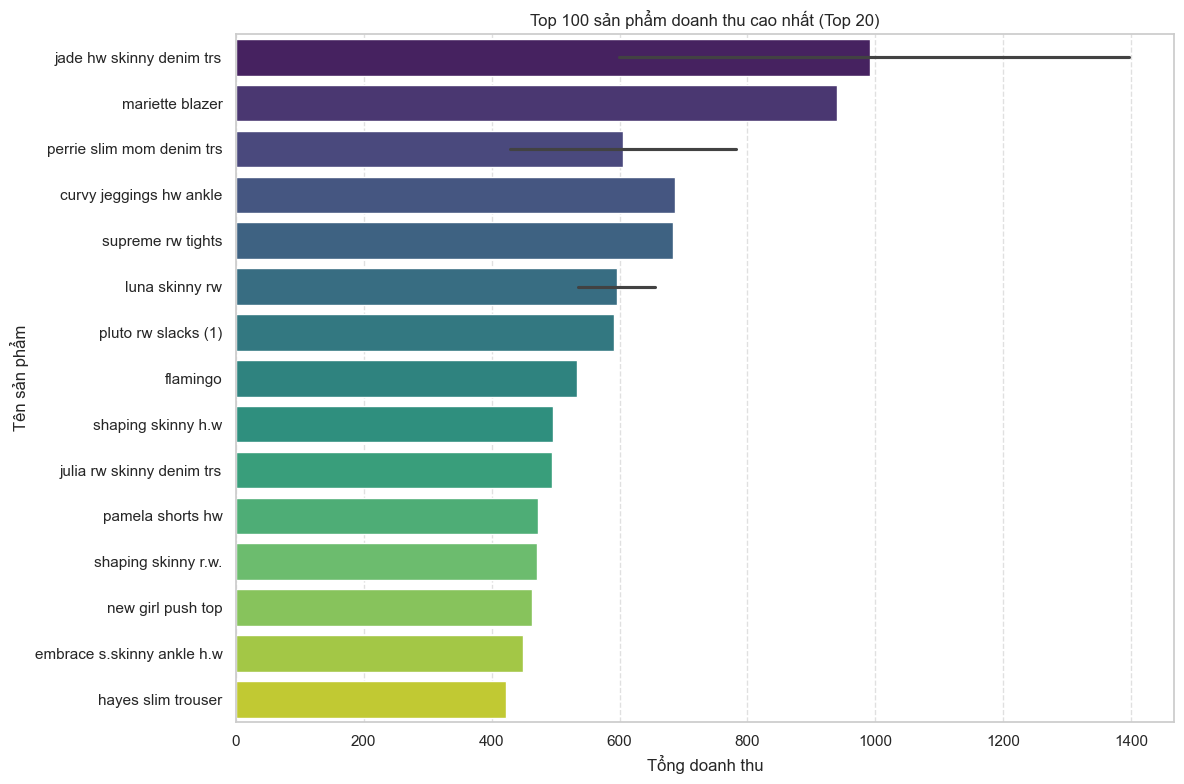

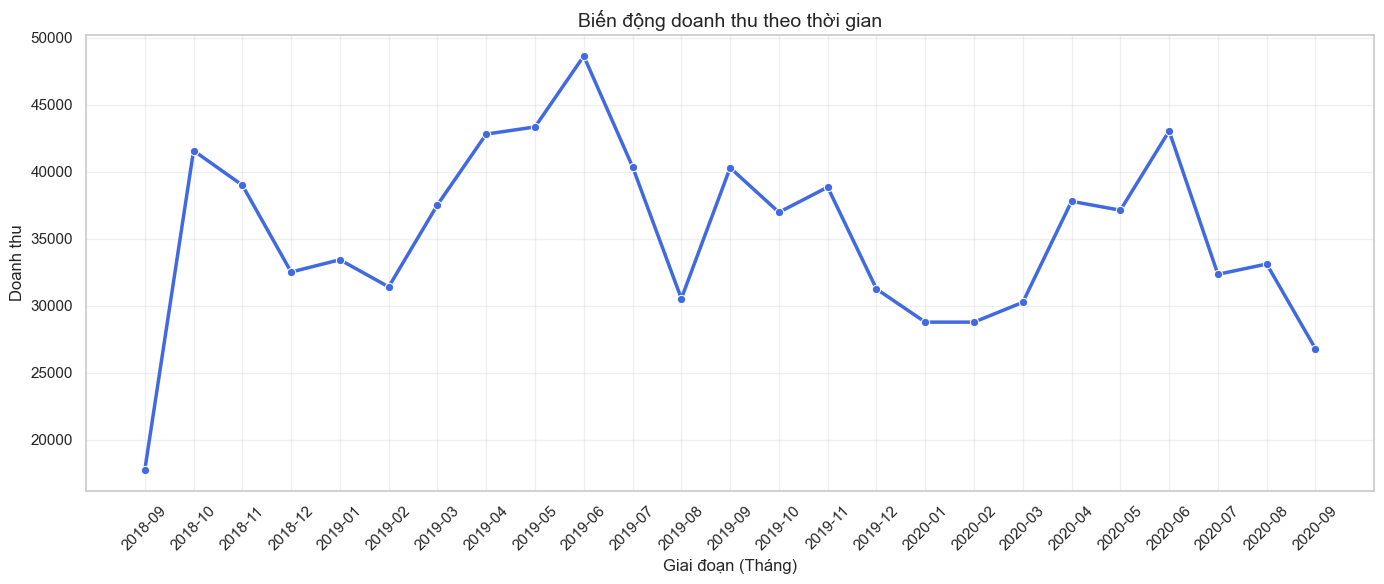

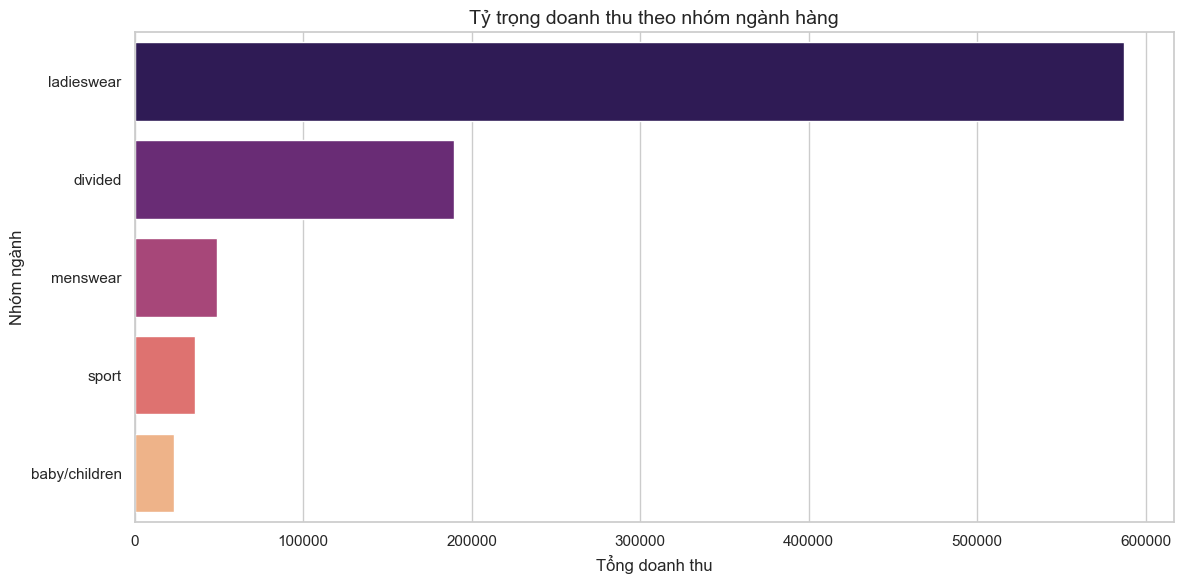

Đang xây dựng RFM và tiền xử lý cho K-Means...
RFM hoàn tất: 837609 khách hàng.
RFM đã được chuẩn hóa toán học và sẵn sàng cho K-Means.
👥 Đang thực hiện Customer EDA...


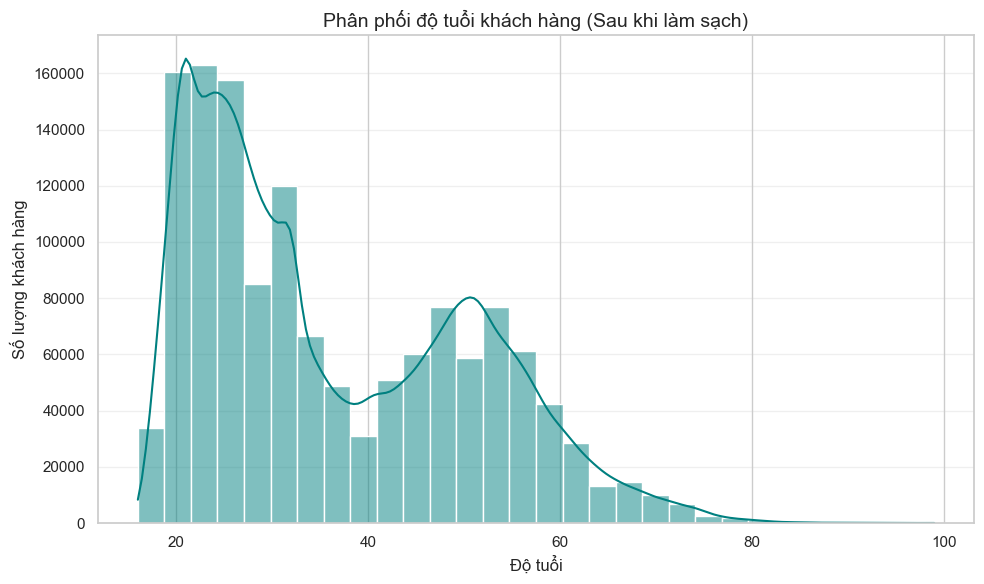

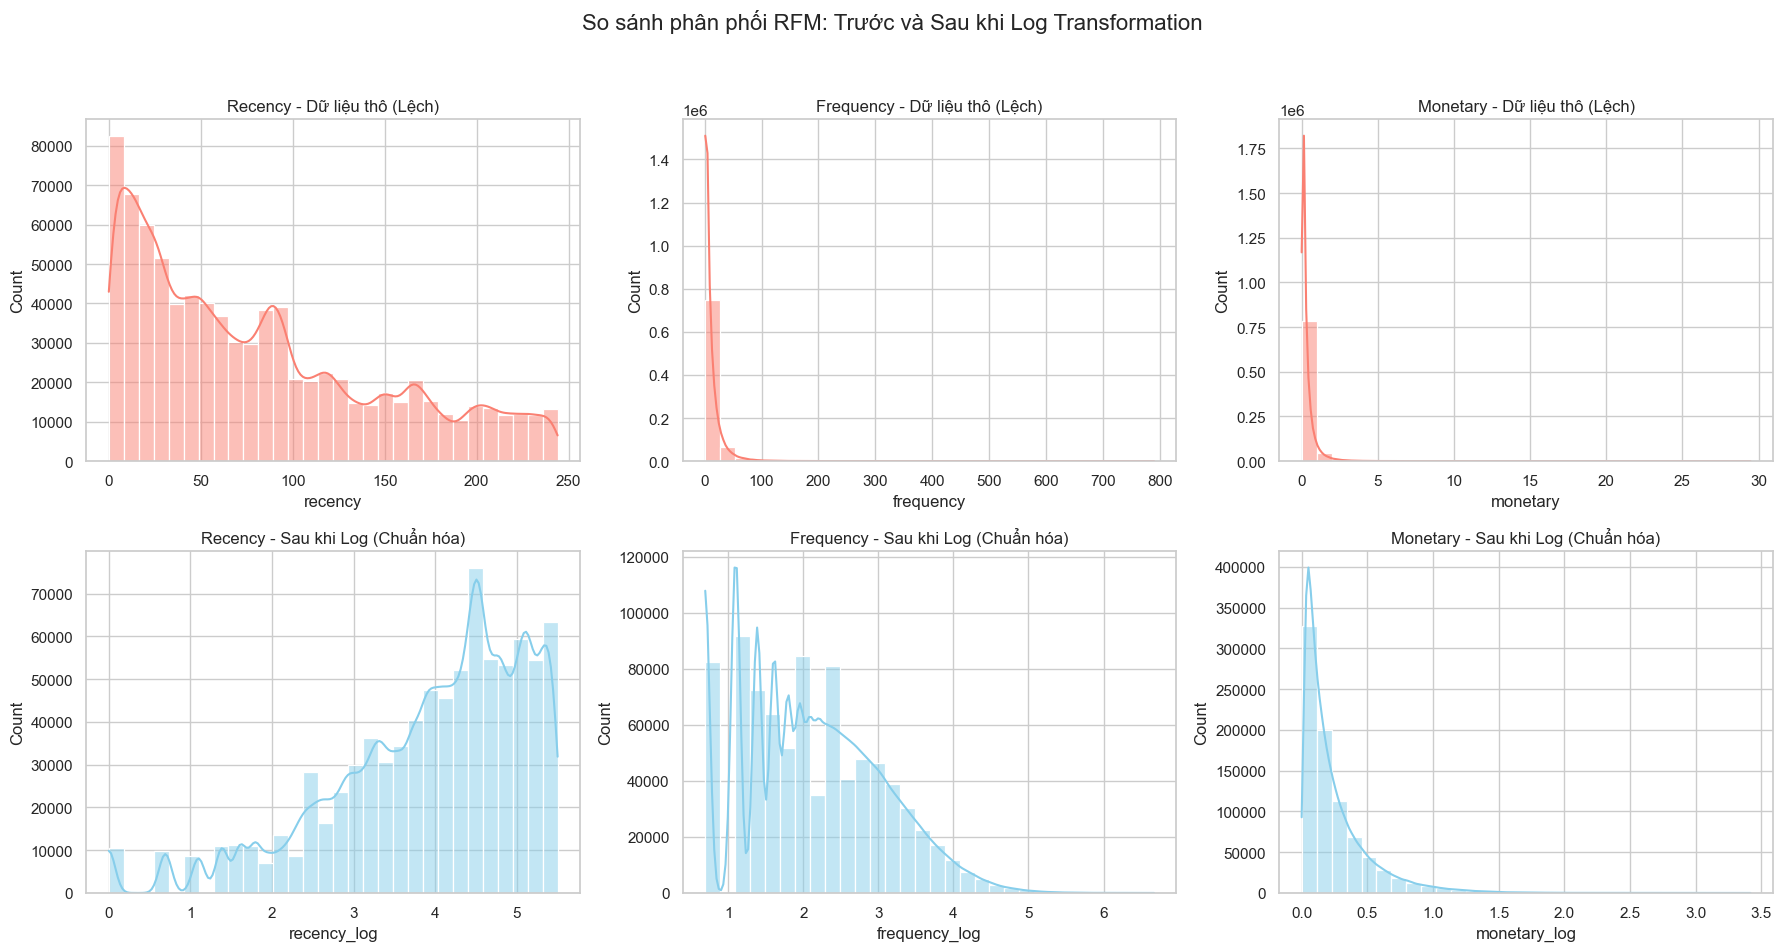

C:\Users\Admin\AppData\Local\Temp\ipykernel_3680\2839236023.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf, x="club_member_status", y="total_spending", ax=ax[0], palette="magma")


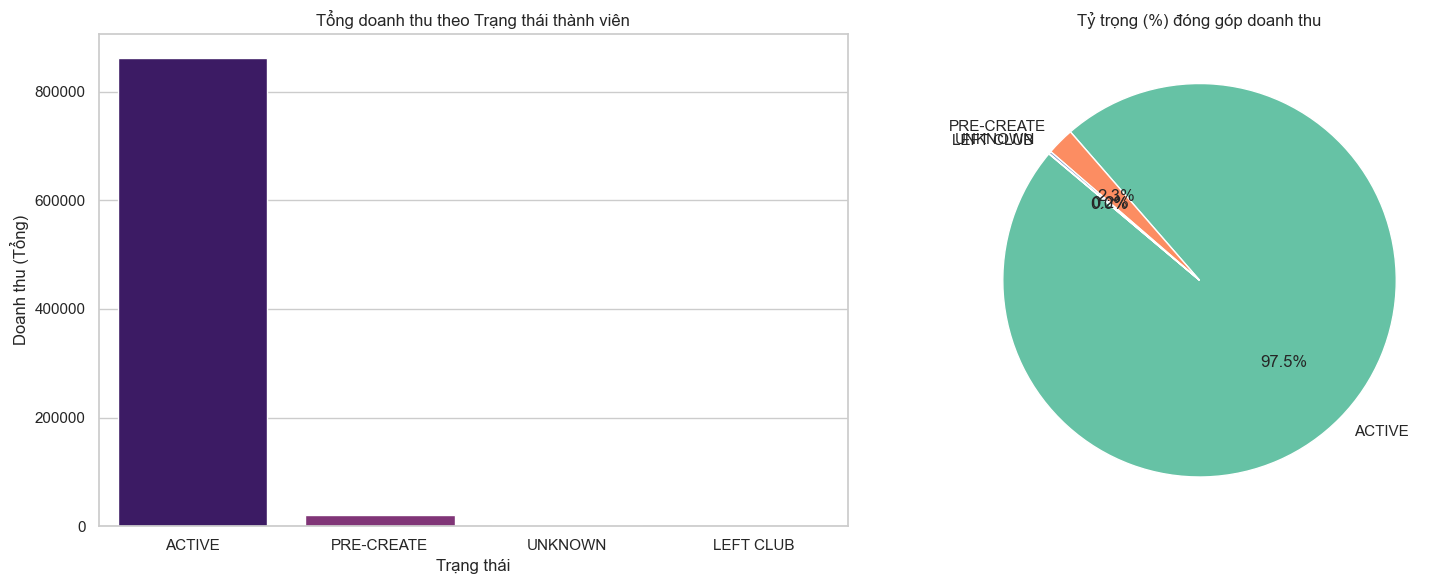

C:\Users\Admin\AppData\Local\Temp\ipykernel_3680\2839236023.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf, x="club_member_status", y="avg_spending_per_customer", palette="viridis")


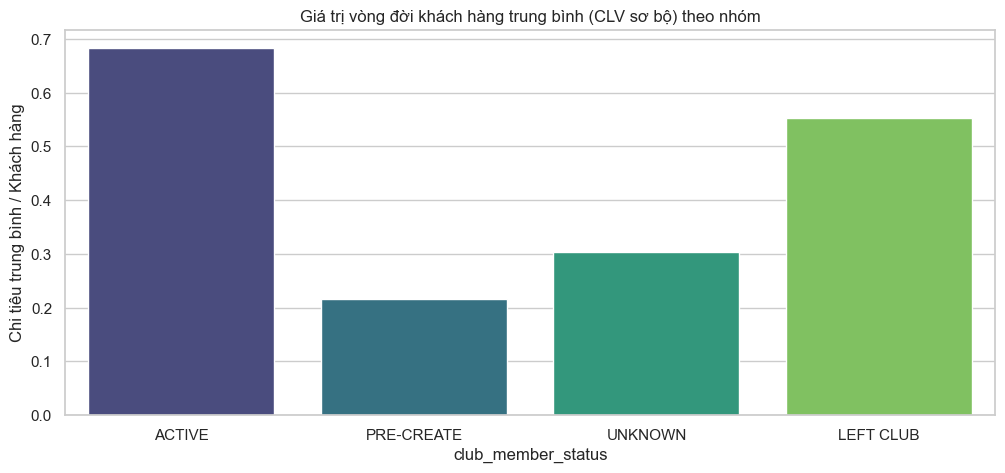

Pipeline hoàn tất thành công!


In [24]:


    # =========================
    # 8) MAIN EXECUTION (SỬA LỖI & TỐI ƯU)
    # =========================

    def build_member_status_stats(tx_lf: pl.LazyFrame, customers_df: pl.DataFrame) -> pl.DataFrame:
        """
        Tính toán thống kê theo trạng thái thành viên.
        SỬA: Sử dụng inner join để đảm bảo dữ liệu chính xác và đồng nhất.
        """
        # Chuyển customers_df sang Lazy để join tối ưu
        customers_lf = customers_df.lazy().select(["customer_id", "club_member_status"])

        member_stats = (
            tx_lf.join(customers_lf, on="customer_id", how="inner")
            .with_columns([
                pl.col("club_member_status").fill_null("UNKNOWN").alias("club_member_status")
            ])
            .group_by("club_member_status")
            .agg([
                pl.len().alias("num_transactions"),
                pl.col("price").sum().alias("total_spending"),
                pl.col("price").mean().alias("avg_order_value"),
                pl.col("customer_id").n_unique().alias("num_customers"),
            ])
            .with_columns([
                (pl.col("num_transactions") / pl.col("num_customers")).alias("avg_transactions_per_customer"),
                (pl.col("total_spending") / pl.col("num_customers")).alias("avg_spending_per_customer"),
            ])
            .sort("num_transactions", descending=True)
            .collect()
        )
        return member_stats

    def run_full_pipeline() -> None:
        print("Bắt đầu chạy Full Pipeline...")
        HMConfig.OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

        # 1. Ingestion & Light Parquet
        tx_lf = scan_transactions_lazy(HMConfig.TRANSACTIONS_CSV)
        build_transaction_light_parquet(HMConfig.TRANSACTIONS_CSV, HMConfig.OUTPUT_DIR / "transactions_light.parquet")

        # 2. Subset 6 tháng để test nhanh
        recent_df = save_recent_months_subset(tx_lf, months_back=6)
        print(f"Recent subset created. Shape: {recent_df.shape}")

        # 3. Cleaning danh mục
        customers_df = clean_customers(HMConfig.CUSTOMERS_CSV)
        articles_df = clean_articles(HMConfig.ARTICLES_CSV)
        articles_lf = articles_df.lazy()

        # 4. Product EDA
        print("Đang thực hiện Product EDA...")
        top_rev = top_100_products(tx_lf, articles_lf, metric="revenue")
        plot_monthly_revenue(tx_lf)
        plot_index_group_revenue(tx_lf, articles_df)

        # 5. RFM & Clustering Preparation
        print("Đang xây dựng RFM và tiền xử lý cho K-Means...")
        rfm_df = build_rfm(tx_lf, months_back=8)

        # GIẢI QUYẾT TODO: Kiểm tra tính nhất quán (Data Integrity)
        # Lọc bỏ khách hàng không có trong bảng customers sạch
        clean_cust_ids = customers_df.select("customer_id")
        rfm_df = rfm_df.join(clean_cust_ids, on="customer_id", how="inner")

        # Tiền xử lý (Log + Scale)
        rfm_pd, X_scaled = prepare_rfm_for_clustering(rfm_df)

        # 6. Customer EDA & Stats
        print("👥 Đang thực hiện Customer EDA...")
        plot_age_distribution(customers_df)

        # Vẽ biểu đồ RFM Before/After Log (Đã dời từ hàm stats lên đây)
        plot_rfm_before_after_log(rfm_pd)

        # Thống kê Membership
        m_stats = build_member_status_stats(tx_lf, customers_df)
        plot_customer_membership_eda(tx_lf, customers_df)

        print("Pipeline hoàn tất thành công!")

    if __name__ == "__main__":
        run_full_pipeline()